In [1]:
!pip install transformers torch sentencepiece sacremoses

In [33]:
# !pip install rouge-score sacrebleu

In [35]:
!pip install rouge-score sacrebleu


  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Created wheel for rouge-score: filename=rouge_score-0.1.2-py3-none-any.whl size=24971 sha256=9aa218a24bdfbd44e568464841ef8440ed118843fb2faf733940a17eabda3c3e
  Stored in directory: c:\users\user\appdata\local\pip\cache\wheels\44\af\da\5ffc433e2786f0b1a9c6f458d5fb8f611d8eb332387f18698f
Successfully built rouge-score

   ---------------------------------------- 3/3 [rouge-score]



  DEPRECATION: Building 'rouge-score' using the legacy setup.py bdist_wheel mechanism, which will be removed in a future version. pip 25.3 will enforce this behaviour change. A possible replacement is to use the standardized build interface by setting the `--use-pep517` option, (possibly combined with `--no-build-isolation`), or adding a `pyproject.toml` file to the source tree of 'rouge-score'. Discussion can be found at https://github.com/pypa/pip/issues/6334


In [51]:
import torch
import torch.nn.functional as F
import math
import matplotlib.pyplot as plt
from transformers import (M2M100ForConditionalGeneration, M2M100Tokenizer, 
                          T5ForConditionalGeneration, T5Tokenizer, 
                          AutoTokenizer, AutoModelForSeq2SeqLM, 
                          AutoModelForTokenClassification, pipeline)
from rouge_score import rouge_scorer
import sacrebleu

In [52]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_m2m_name = "facebook/m2m100_418M"
tokenizer_m2m = M2M100Tokenizer.from_pretrained(model_m2m_name)
model_m2m = M2M100ForConditionalGeneration.from_pretrained(model_m2m_name).to(device)

Loading weights:   0%|          | 0/512 [00:00<?, ?it/s]

In [53]:
news_text = """
The SpaceX Starship spacecraft successfully completed its latest test flight, 
achieving a historic milestone by splashing down in the Indian Ocean. 
The mission was designed to test the vehicle's heat shield and steering capabilities 
during reentry. Elon Musk stated that the data is invaluable for Mars missions.
"""

In [54]:
scorer = rouge_scorer.RougeScorer(['rouge1', 'rougeL'], use_stemmer=True)
reference_ru = """Космический корабль SpaceX Starship успешно завершил свой последний испытательный полет, 
достигнув исторической вехи, приводнившись в Индийском океане. 
Миссия была разработана для проверки теплозащитного экрана и возможностей управления кораблем 
во время входа в атмосферу. Илон Маск заявил, что полученные данные бесценны для миссий на Марс."""
reference_summ_en = "SpaceX Starship completed its test flight and splashed down in the Indian Ocean, providing data for Mars."

In [55]:
#Саммари (T5-Small)
summ_name = "t5-small"
summ_tokenizer = T5Tokenizer.from_pretrained(summ_name, legacy=False)
summ_model = T5ForConditionalGeneration.from_pretrained(summ_name).to(device)

Loading weights:   0%|          | 0/131 [00:00<?, ?it/s]

In [56]:
input_ids = summ_tokenizer.encode("summarize: " + news_text, return_tensors="pt", truncation=True).to(device)
outputs = summ_model.generate(input_ids, max_length=50, min_length=10, num_beams=4, early_stopping=True)
summary_text = summ_tokenizer.decode(outputs[0], skip_special_tokens=True)
print(f"Саммари(EN): {summary_text}")

encoded_summ = tokenizer_m2m(summary_text, return_tensors="pt").to(device)
generated_tokens = model_m2m.generate(**encoded_summ, forced_bos_token_id=tokenizer_m2m.get_lang_id("ru"))
translated_summary = tokenizer_m2m.batch_decode(generated_tokens, skip_special_tokens=True)[0]
print(f"Саммари(RU): {translated_summary}")

Саммари(EN): the spacecraft successfully completed its latest test flight. the mission was designed to test the vehicle's heat shield and steering capabilities during reentry.
Саммари(RU): Космический корабль успешно завершил свой последний испытательный полет. миссия была разработана для тестирования теплового щита транспортного средства и управляющих способностей во время возвращения.


In [57]:
score_t5 = scorer.score(reference_summ_en, summary_text)
print(f"Метрика ROUGE-1 для T5: {score_t5['rouge1'].fmeasure:.2f}")

Метрика ROUGE-1 для T5: 0.29


In [58]:
# Саммари (PEGASUS) + Перевод
from transformers import PegasusForConditionalGeneration, PegasusTokenizer
model_pegasus_name = "google/pegasus-xsum"
tokenizer_pegasus = PegasusTokenizer.from_pretrained(model_pegasus_name)
model_pegasus = PegasusForConditionalGeneration.from_pretrained(model_pegasus_name).to(device)
tokens_pegasus = tokenizer_pegasus(news_text, truncation=True, padding="longest", return_tensors="pt").to(device)

summary_pegasus_ids = model_pegasus.generate(**tokens_pegasus, max_length=60, num_beams=5, early_stopping=True)
summary_pegasus = tokenizer_pegasus.decode(summary_pegasus_ids[0], skip_special_tokens=True)
print(f"Саммари(EN): {summary_pegasus}")

enc_peg = tokenizer_m2m(summary_pegasus, return_tensors="pt").to(device)
gen_peg = model_m2m.generate(**enc_peg, forced_bos_token_id=tokenizer_m2m.get_lang_id("ru"))
tr_pegasus = tokenizer_m2m.batch_decode(gen_peg, skip_special_tokens=True)[0]
print(f"Саммари(RU): {tr_pegasus}")


Loading weights:   0%|          | 0/680 [00:00<?, ?it/s]

PegasusForConditionalGeneration LOAD REPORT from: google/pegasus-xsum
Key                                  | Status  | 
-------------------------------------+---------+-
model.decoder.embed_positions.weight | MISSING | 
model.encoder.embed_positions.weight | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Саммари(EN): The world's largest rocket has returned to Earth.
Саммари(RU): Самая большая ракета в мире вернулась на Землю.


In [59]:
score_peg = scorer.score(reference_summ_en, summary_pegasus)
print(f"Метрика ROUGE-1 для Pegasus: {score_peg['rouge1'].fmeasure:.2f}")

Метрика ROUGE-1 для Pegasus: 0.08


In [60]:
# Переаод (Helsinki-NLP) ---
tr_name = "Helsinki-NLP/opus-mt-en-ru"
tr_tokenizer = AutoTokenizer.from_pretrained(tr_name)
tr_model = AutoModelForSeq2SeqLM.from_pretrained(tr_name).to(device)

tr_input_ids = tr_tokenizer.encode(news_text, return_tensors="pt", truncation=True).to(device)
tr_outputs = tr_model.generate(tr_input_ids)
translated_text = tr_tokenizer.decode(tr_outputs[0], skip_special_tokens=True)
print(f"Перевод:\n{translated_text}")

Loading weights:   0%|          | 0/258 [00:00<?, ?it/s]

Перевод:
Космический корабль &quot; Спейс Х &quot; успешно завершил свой последний испытательный полет, достигнув исторической вехи, сорвавшись в Индийском океане. &quot; Космический корабль &quot; был создан для проверки теплозащиты и рулевой способности транспортного средства во время возвращения в атмосферу. &quot; Элон Маск &quot; заявил, что данные бесценны для космических полетов на Марсе.


In [61]:
bleu_full = sacrebleu.corpus_bleu([translated_full], [[reference_ru]])
print(f"Метрика BLEU для полного перевода Helsinki-NLP: {bleu_full.score:.2f}")

Метрика BLEU для полного перевода Helsinki-NLP: 28.04


In [62]:
# Перевод (M2M100 (Facebook))
from transformers import M2M100ForConditionalGeneration, M2M100Tokenizer

model_m2m = "facebook/m2m100_418M"
tokenizer_m2m = M2M100Tokenizer.from_pretrained(model_m2m)
model_m2m = M2M100ForConditionalGeneration.from_pretrained(model_m2m).to(device)
tokenizer_m2m.src_lang = "en"

encoded_en = tokenizer_m2m(news_text, return_tensors="pt", truncation=True).to(device)
generated_tokens = model_m2m.generate(**encoded_en, forced_bos_token_id=tokenizer_m2m.get_lang_id("ru"))
translated_full = tokenizer_m2m.batch_decode(generated_tokens, skip_special_tokens=True)[0]
print(f"Перевод:\n{translated_full}")

Loading weights:   0%|          | 0/512 [00:00<?, ?it/s]

Перевод:
Космический корабль SpaceX Starship успешно завершил свой последний испытательный полет, достигая исторического мильстона, спускаясь в Индийский океан. Миссия была разработана для тестирования теплового щита транспортного средства и управления способностями во время реинтеграции.


In [63]:
bleu_summ = sacrebleu.corpus_bleu([translated_summary], [[reference_ru]])
print(f"Метрика BLEU для перевода M2M100 : {bleu_summ.score:.2f}")

Метрика BLEU для перевода M2M100 : 10.68


In [64]:
# Токенизация
tokens = summ_tokenizer.tokenize(summary_text)
token_ids = summ_tokenizer.convert_tokens_to_ids(tokens)
print(f"{'Токен':<15} | {'ID':<10}")
print("-" * 28)
for t, tid in zip(tokens[:5], token_ids[:5]):
    print(f"{t:<15} | {tid:<10}")

Токен           | ID        
----------------------------
▁the            | 8         
▁space          | 628       
craft           | 6696      
▁successfully   | 4234      
▁completed      | 2012      


In [17]:
# Извлечение сущн.(BERT для NER)
ner_model_name = "dbmdz/bert-large-cased-finetuned-conll03-english"
ner_tokenizer = AutoTokenizer.from_pretrained(ner_model_name)
ner_model = AutoModelForTokenClassification.from_pretrained(ner_model_name).to(device)
ner_pipe = pipeline("ner", model=ner_model, tokenizer=ner_tokenizer, 
                    aggregation_strategy="simple", device=0 if torch.cuda.is_available() else -1) #aggregation_strategy="simple" склеить слова в одну сущность
entities = ner_pipe(news_text)

print(f"{'Объект':<20} | {'Тип':<10}")
seen_entities = set() #убрает дублирлвание 
for ent in entities:
    entity_info = f"{ent['word']}:{ent['entity_group']}"
    if entity_info not in seen_entities:
        print(f"{ent['word']:<20} | {ent['entity_group']:<10}")
        seen_entities.add(entity_info)

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

BertForTokenClassification LOAD REPORT from: dbmdz/bert-large-cased-finetuned-conll03-english
Key                      | Status     |  | 
-------------------------+------------+--+-
bert.pooler.dense.weight | UNEXPECTED |  | 
bert.pooler.dense.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Объект               | Тип       
SpaceX Starship      | MISC      
Indian Ocean         | LOC       
Elon Musk            | PER       
Mars                 | MISC      


In [67]:
true_entities = {
    'SpaceX': 'ORG',
    'Starship': 'MISC',
    'Indian Ocean': 'LOC',
    'Elon Musk': 'PER',
    'Mars': 'LOC'
}
pred_entities = {ent['word']: ent['entity_group'] for ent in entities}
true_positives = 0
for word, tag in pred_entities.items():
    if word in true_entities and true_entities[word] == tag:
        true_positives += 1
precision = true_positives / len(pred_entities) if len(pred_entities) > 0 else 0 #Точность(сколько совпало по имени)
recall = true_positives / len(true_entities) if len(true_entities) > 0 else 0 # Полнота (сколько из всех нашла)
f1_ner = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0 #Среднее гармоническое между точностью и полнотой

print(f"Точность (Precision): {precision:.2f}")
print(f"Полнота (Recall):{recall:.2f}")
print(f"F1:{f1_ner:.2f}")


Точность (Precision): 0.50
Полнота (Recall):0.40
F1:0.44


In [18]:
!pip install spacy
!python -m spacy download en_core_web_md

     ---------------------------------------- 0.0/33.5 MB ? eta -:--:--
     - -------------------------------------- 1.0/33.5 MB 9.1 MB/s eta 0:00:04
     --------------- ----------------------- 13.4/33.5 MB 44.1 MB/s eta 0:00:01
     --------------------------- ----------- 23.3/33.5 MB 46.7 MB/s eta 0:00:01
     ---------------------------- ---------- 24.6/33.5 MB 34.6 MB/s eta 0:00:01
     ------------------------------ -------- 26.0/33.5 MB 28.5 MB/s eta 0:00:01
     --------------------------------- ----- 28.8/33.5 MB 25.5 MB/s eta 0:00:01
     --------------------------------------  33.3/33.5 MB 25.1 MB/s eta 0:00:01
     --------------------------------------- 33.5/33.5 MB 24.4 MB/s eta 0:00:00
[+] Download and installation successful
You can now load the package via spacy.load('en_core_web_md')


In [19]:
import spacy

nlp = spacy.load("en_core_web_md")
doc = nlp(news_text)

print(f"{'Объект':<20} | {'Тип':<10} | {'Перевод (RU)':<20}")
seen_spacy = set()
for ent in doc.ents:
    if ent.text not in seen_spacy:
        enc_ent = tokenizer_m2m(ent.text, return_tensors="pt").to(device)
        gen_ent = model_m2m.generate(**enc_ent, forced_bos_token_id=tokenizer_m2m.get_lang_id("ru"))
        tr_ent = tokenizer_m2m.batch_decode(gen_ent, skip_special_tokens=True)[0]
        
        print(f"{ent.text:<20} | {ent.label_:<10} | {tr_ent:<20}")
        seen_spacy.add(ent.text)

Объект               | Тип        | Перевод (RU)        
SpaceX               | PRODUCT    | SpaceX              
Starship             | PRODUCT    | Старый корабль      
the Indian Ocean     | LOC        | Индийский океан     
Elon Musk            | PERSON     | Элон Маск           
Mars                 | LOC        | Марс                


In [69]:
#Attention ручной
def manual_scaled_dot_product_attention(query, key, value):
    d_k = query.size(-1)
    #Скалярное произведение
    scores = torch.matmul(query, key.transpose(-2, -1)) / math.sqrt(d_k)
    print(f"Размер матрицы: {scores.shape}")
    # Распределение весов, [0, 0, :] чтобы запринтить веса только для первого слова в батче
    weights = F.softmax(scores, dim=-1)
    row_sum = weights[0, 0, :].sum().item()
    print(f"Сумма весов одной строки: {row_sum:.1f}") #должна быть 1.0
    # Взвешенная сумма
    output = torch.matmul(weights, value)
    print(f"Размер входного тензора: {output.shape}")
    return output, weights

Размер матрицы: torch.Size([1, 12, 12])
Сумма весов одной строки: 1.0
Размер входного тензора: torch.Size([1, 12, 1024])


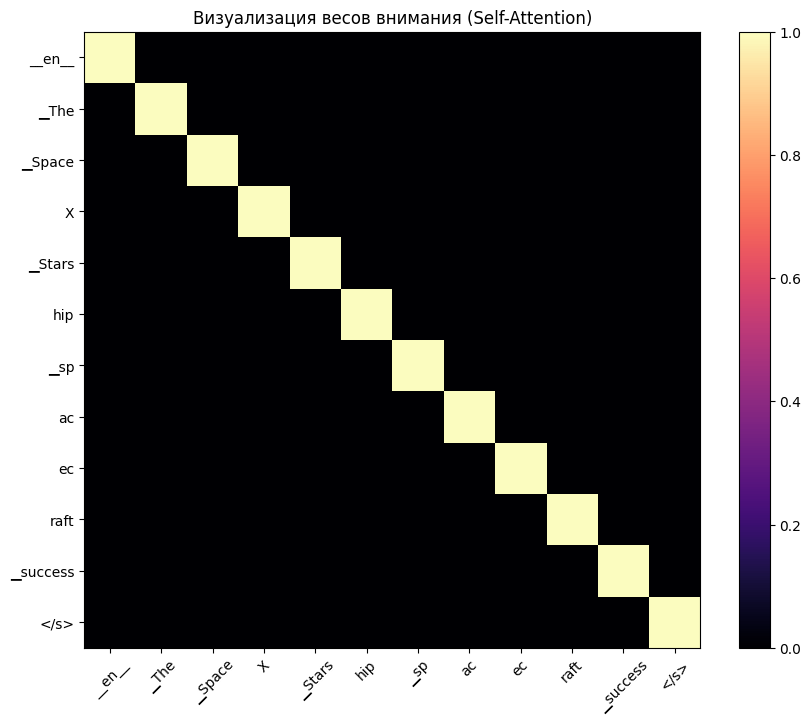

In [70]:
inputs = tokenizer_m2m(news_text, return_tensors="pt", truncation=True, max_length=12).to(device)

with torch.no_grad():
    embeddings = model_m2m.get_input_embeddings()(inputs['input_ids'])
output, attn_weights = manual_scaled_dot_product_attention(embeddings, embeddings, embeddings)

plt.figure(figsize=(10, 8))
weights_matrix = attn_weights[0].cpu().detach().numpy() #убираем батч индекс 0
tokens_list = tokenizer_m2m.convert_ids_to_tokens(inputs['input_ids'][0])
clean_tokens = [t.replace(' ', '') for t in tokens_list]

plt.imshow(weights_matrix, cmap='magma')
plt.xticks(range(len(clean_tokens)), clean_tokens, rotation=45)
plt.yticks(range(len(clean_tokens)), clean_tokens)
plt.title("Визуализация весов внимания (Self-Attention)")
plt.colorbar()
plt.show()

Размер матрицы: torch.Size([1, 12, 12])
Сумма весов одной строки: 1.0
Размер входного тензора: torch.Size([1, 12, 1024])


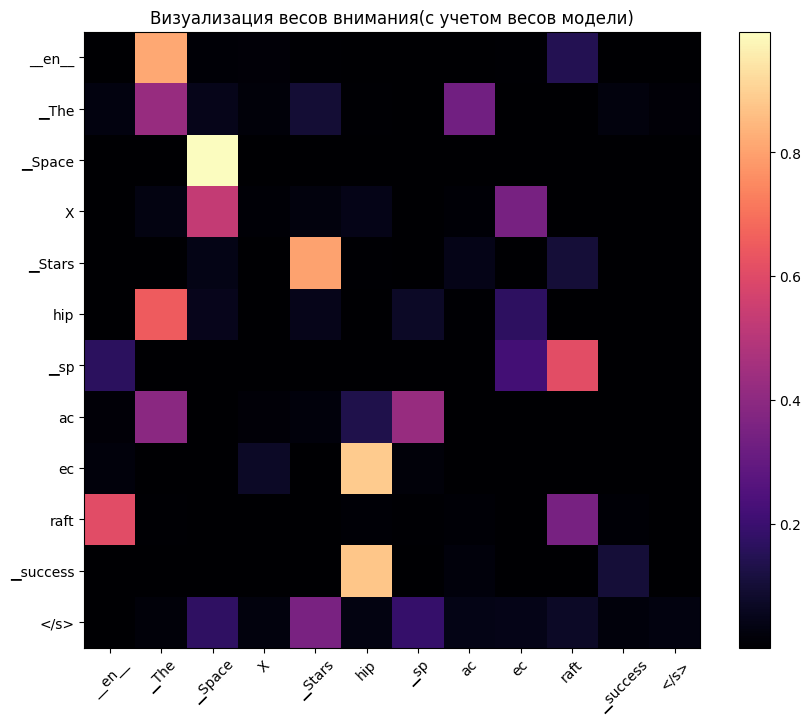

In [71]:
# + веса модели для проекций Q и K
with torch.no_grad():
    q_layer = model_m2m.model.encoder.layers[0].self_attn.q_proj
    k_layer = model_m2m.model.encoder.layers[0].self_attn.k_proj
    Q = q_layer(embeddings)
    K = k_layer(embeddings)
output_smart, weights_smart = manual_scaled_dot_product_attention(Q, K, embeddings)

plt.figure(figsize=(10, 8))
matrix_to_plot = weights_smart[0].cpu().detach().numpy()
plt.imshow(matrix_to_plot, cmap='magma')
plt.xticks(range(len(clean_tokens)), clean_tokens, rotation=45)
plt.yticks(range(len(clean_tokens)), clean_tokens)
plt.title("Визуализация весов внимания(с учетом весов модели)")
plt.colorbar()
plt.show()